In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

import warnings
warnings.filterwarnings('ignore')

In [36]:
from google.colab import files

uploaded = files.upload()

Saving DailyDelhiClimateTest.csv to DailyDelhiClimateTest.csv


In [37]:
df = pd.read_csv(
    "DailyDelhiClimateTrain.csv"
)

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [39]:
df.shape

(1462, 5)

In [40]:
df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [41]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [42]:
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [43]:
df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['day'] = df['date'].dt.day

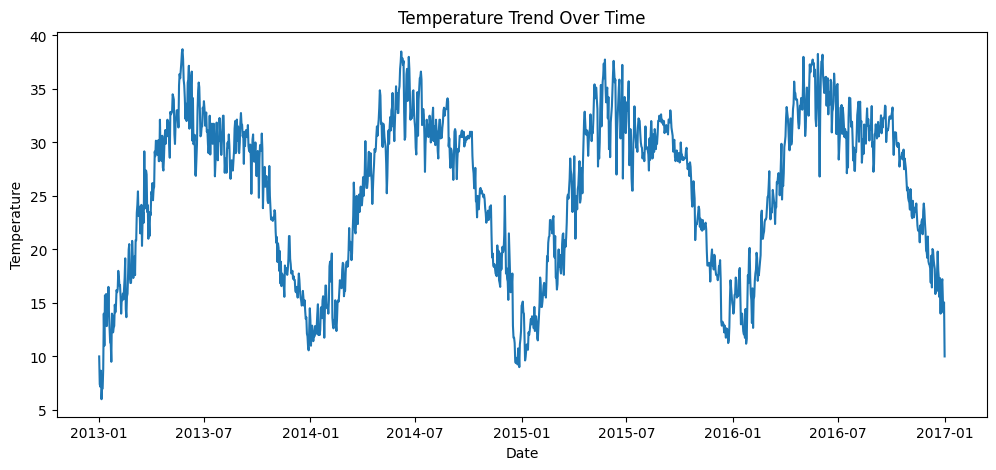

In [44]:
plt.figure(figsize=(12,5))

plt.plot(
    df['date'],
    df['meantemp']
)

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.title(
    "Temperature Trend Over Time"
)

plt.show()

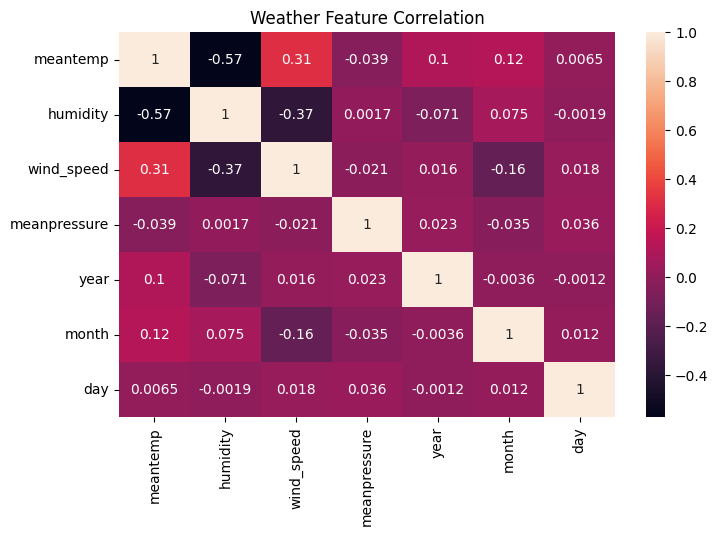

In [45]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title(
    "Weather Feature Correlation"
)

plt.show()

In [46]:
X = df[
[
'humidity',
'wind_speed',
'meanpressure',
'month',
'day'
]
]


y = df['meantemp']

In [47]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1169, 5)
Testing Data: (293, 5)


In [48]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()


lr_model.fit(
    X_train,
    y_train
)


print("Linear Regression Training Completed")

Linear Regression Training Completed


In [49]:
lr_prediction = lr_model.predict(
    X_test
)


lr_prediction[:10]

array([32.91035716, 20.8850793 , 24.25257907, 35.7704568 , 24.2408531 ,
       23.67990074, 19.62406542, 22.81616903, 25.97479637, 31.1136052 ])

In [50]:
lr_mae = mean_absolute_error(
    y_test,
    lr_prediction
)


print(
    "Mean Absolute Error:",
    lr_mae
)

Mean Absolute Error: 5.01240706336279


In [51]:
lr_mse = mean_squared_error(
    y_test,
    lr_prediction
)


print(
    "Mean Squared Error:",
    lr_mse
)

Mean Squared Error: 37.13646693769247


In [52]:
lr_rmse = np.sqrt(lr_mse)


print(
    "RMSE:",
    lr_rmse
)

RMSE: 6.093969719131567


In [53]:
lr_r2 = r2_score(
    y_test,
    lr_prediction
)


print(
    "R2 Score:",
    lr_r2
)

R2 Score: 0.3092103111567934


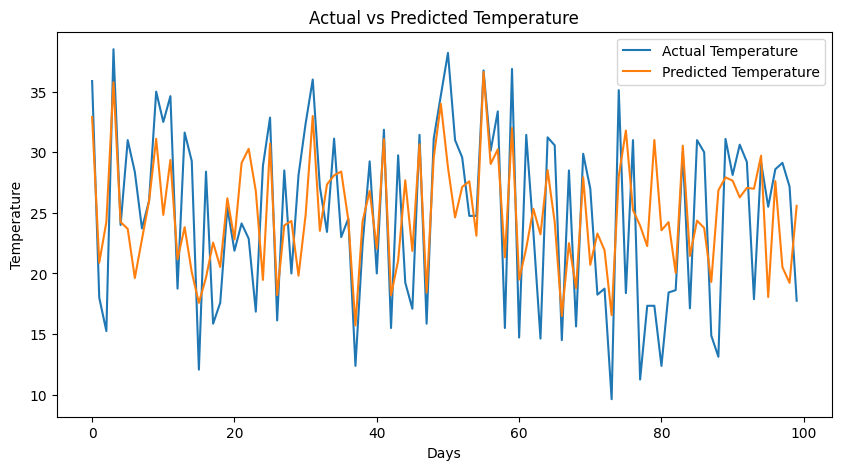

In [54]:
plt.figure(figsize=(10,5))


plt.plot(
    y_test.values[:100],
    label="Actual Temperature"
)


plt.plot(
    lr_prediction[:100],
    label="Predicted Temperature"
)


plt.xlabel("Days")

plt.ylabel("Temperature")


plt.title(
    "Actual vs Predicted Temperature"
)


plt.legend()

plt.show()

In [55]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


print(
    "Random Forest Training Completed"
)

Random Forest Training Completed


In [56]:
rf_prediction = rf_model.predict(
    X_test
)


rf_prediction[:10]

array([35.20541667, 15.72627335, 17.31305952, 37.37142857, 22.36989487,
       30.64429938, 28.50011548, 24.36357143, 28.86410521, 35.093375  ])

In [57]:
rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)


rf_mse = mean_squared_error(
    y_test,
    rf_prediction
)


rf_rmse = np.sqrt(
    rf_mse
)


rf_r2 = r2_score(
    y_test,
    rf_prediction
)


print(
    "MAE:",
    rf_mae
)


print(
    "RMSE:",
    rf_rmse
)


print(
    "R2 Score:",
    rf_r2
)

MAE: 1.465373427411738
RMSE: 2.0274402465484314
R2 Score: 0.9235387507495878


In [58]:
results = pd.DataFrame(
{
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "R2 Score":[
        lr_r2,
        rf_r2
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse
    ]
}
)


results

,Model,R2 Score,RMSE
0,Linear Regression,0.309210,6.09397
1,Random Forest,0.923539,2.02744


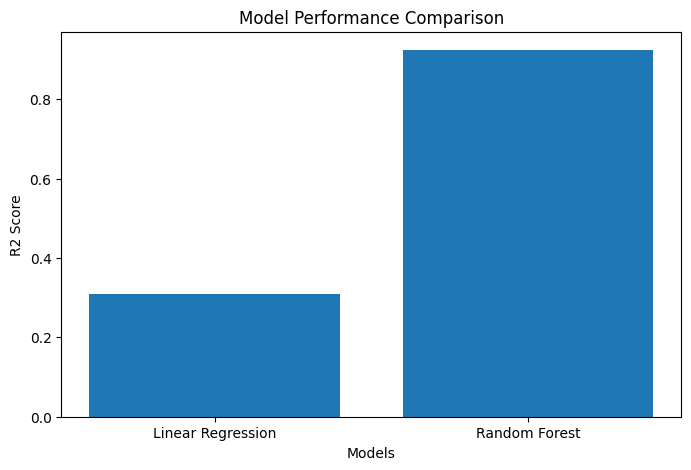

In [59]:
plt.figure(figsize=(8,5))


plt.bar(
    results["Model"],
    results["R2 Score"]
)


plt.xlabel("Models")

plt.ylabel("R2 Score")


plt.title(
    "Model Performance Comparison"
)


plt.show()

In [60]:
importance = pd.DataFrame(
{
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
}
)


importance

,Feature,Importance
0,humidity,0.076015
1,wind_speed,0.012808
2,meanpressure,0.830861
3,month,0.059288
4,day,0.021028


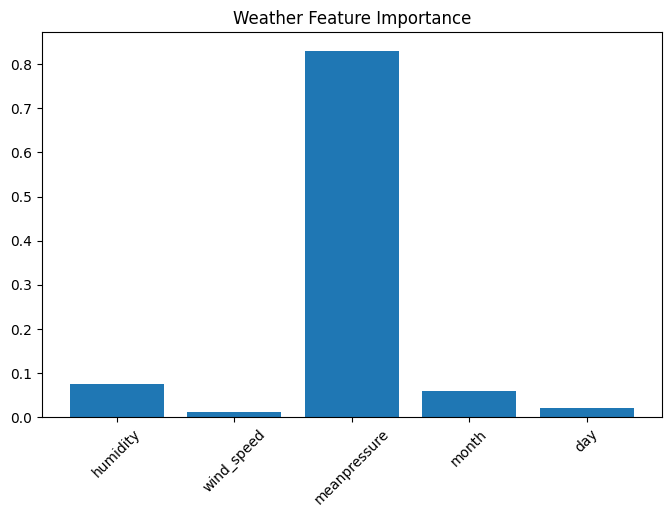

In [61]:
plt.figure(figsize=(8,5))


plt.bar(
    importance["Feature"],
    importance["Importance"]
)


plt.xticks(
    rotation=45
)


plt.title(
    "Weather Feature Importance"
)


plt.show()

In [62]:
import joblib


joblib.dump(
    rf_model,
    "weather_model.pkl"
)


print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [67]:
loaded_model = joblib.load(
    "weather_model.pkl"
)


print(
    "Model Loaded Successfully"
)

Model Loaded Successfully


In [64]:
future_weather = np.array(
[
    [
        60,
        2,
        1010,
        7,
        28
    ]
]
)


future_temperature = loaded_model.predict(
    future_weather
)


print(
    "Predicted Temperature:",
    future_temperature[0],
    "°C"
)

Predicted Temperature: 26.15729828042328 °C


In [65]:
df.to_csv(
    "processed_weather_data.csv",
    index=False
)

print(
    "Processed Dataset Saved"
)

Processed Dataset Saved
